# 050. 형태소 분석 (POS tag, part-of-speech tag)

- 품사 부착 혹은 POS tag (part-of-speech tag) 라 부름  

- 원시 말뭉치를 형태소 단위로 쪼개고 각 형태소에 품사 정보를 부착하는 작업  

- 형태소는 언어별로 다르고, 비슷한 언어간에는 유사하나 연관성이 없는 단어간에는 완전히 다름  

- 가장 기본적으로는 명사, 동사, 형용사 등으로 나눌 수 있으나 이를 단, 복수형 명사, 동사 변화, 시제 변화 등 더 자세히 나눌 수 있음.  

- 한글의 경우, KoNLPy는 시중에 공개된 꼬꼬마, 코모란, 트위터, 한나눔, 은전한닢 다섯개의 형태소 분석기를 한꺼번에 묶어서 편리하게 사용할 수 있도록 한 패키지

# 형태소의 용도 및 작성법

- 형태소는 각 단어가 어떤 품사인지 고려하여 자동 문장 처리를 가능하도록 한다.  이를 이용하여 언어의 통계적 처리가 가능  

- 영어와 같이 동일한 단어가 다른 품사를 가지는 언어의 경우 품사 tagging 에 의해 그 단어가 명사로 사용 되었는지 동사로 사용되었는지 구분할 수 있다.  

- 수작업 tagging 은 large corpus 에서는 거의 불가능하고, small corpus 에서 training data 용으로 사용  

- 여러 언어를 처리하는 tagger 도 있으나, 각 언어별 tagger 들은 서로 관련성 없을 수 있고, 각각 다른 접근법과 알고리즘 및 프로그램 언어를 사용할 수 있다.

## Keras 를 이용한 LSTM POS tagger 작성

- Bidirectional LSTM 으로 POS tagger 작성  


- nltk 내장 corpus 를 이용하여 training  
    - nltk.corpus.treebank.tagged_sents() 사용

In [0]:
!pip install konlpy

In [0]:
import re
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Embedding, Activation
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
import nltk
from konlpy.tag import Okt

In [3]:
nltk.download('treebank')

[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Package treebank is already up-to-date!


True

In [4]:
tagged_sentences = nltk.corpus.treebank.tagged_sents()

print(tagged_sentences[100])
print()
print(' '.join([word for (word, tag) in tagged_sentences[100]]))
print()
print("Total tagged sentences :", len(tagged_sentences))
print("Total tagged words :", len(nltk.corpus.treebank.tagged_words()))

[('Alan', 'NNP'), ('Spoon', 'NNP'), (',', ','), ('recently', 'RB'), ('named', 'VBN'), ('*', '-NONE-'), ('Newsweek', 'NNP'), ('president', 'NN'), (',', ','), ('said', 'VBD'), ('0', '-NONE-'), ('Newsweek', 'NNP'), ("'s", 'POS'), ('ad', 'NN'), ('rates', 'NNS'), ('would', 'MD'), ('increase', 'VB'), ('5', 'CD'), ('%', 'NN'), ('in', 'IN'), ('January', 'NNP'), ('.', '.')]

Alan Spoon , recently named * Newsweek president , said 0 Newsweek 's ad rates would increase 5 % in January .

Total tagged sentences : 3914
Total tagged words : 100676


### input, label data 작성을 위해 단어와 tag 를 분리

In [5]:
list(zip(*[(1, 'a', 'X'), (2, 'b', 'Y'), (3, 'c', 'Z')]))

[(1, 2, 3), ('a', 'b', 'c'), ('X', 'Y', 'Z')]

In [6]:
sentences, sentence_tags =[], [] 

for tagged_sentence in tagged_sentences:
    sentence, tags = zip(*tagged_sentence)
    sentences.append(list(sentence))
    sentence_tags.append(list(tags))

# Let's see how a sequence looks
print(sentences[5])
print(sentence_tags[5])

['Lorillard', 'Inc.', ',', 'the', 'unit', 'of', 'New', 'York-based', 'Loews', 'Corp.', 'that', '*T*-2', 'makes', 'Kent', 'cigarettes', ',', 'stopped', 'using', 'crocidolite', 'in', 'its', 'Micronite', 'cigarette', 'filters', 'in', '1956', '.']
['NNP', 'NNP', ',', 'DT', 'NN', 'IN', 'JJ', 'JJ', 'NNP', 'NNP', 'WDT', '-NONE-', 'VBZ', 'NNP', 'NNS', ',', 'VBD', 'VBG', 'NN', 'IN', 'PRP$', 'NN', 'NN', 'NNS', 'IN', 'CD', '.']


샘플의 최대 길이 : 271
샘플의 평균 길이 : 25.722024


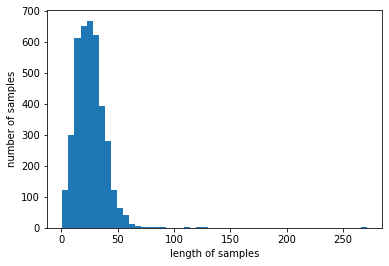

In [7]:
print('샘플의 최대 길이 : {}'.format(max([len(w) for w in sentences])))
print('샘플의 평균 길이 : {:4f}'.format(np.mean([len(w) for w in sentences])))
plt.hist([len(s) for s in sentences], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

**sample 들의 길이가 대체적으로 0-100의 길이를 가지며, 특히 0-50의 길이를 가진 샘플이 상당한 비율을 차지**

**keras 는 fixed size sequence 만 handling 가능하므로 max sequence length 를 100 으로 정함**

In [0]:
MAX_LENGTH = 100

### 전체 word 수 check

In [9]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)

print(len(tokenizer.word_index))

11387


**전체 token 갯수가 11387 개 이므로 embedding 은 상위 4000 개로 제한**

- 문장 데이터에 대해서는 input_tokenizer를, 레이블에 해당되는 개체명 태깅 정보에 대해서는 tag_tokenizer를 사용  

In [0]:
MAX_WORDS = 4000

### train, test split

In [0]:
train_sentences, test_sentences, train_tags, test_tags \
                = train_test_split(sentences, sentence_tags, test_size=0.2)

### train data 는 train_sentences 에 대해 tokenize 하고 label 은 전체 sentence_tags 에 대해 tokenize

- model 은 train 시 validation data 를 볼 수 없어야 함

In [12]:
input_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
input_tokenizer.fit_on_texts(train_sentences)

tag_tokenizer = Tokenizer()
tag_tokenizer.fit_on_texts(sentence_tags)

vocab_size = input_tokenizer.num_words + 1
tag_size = len(tag_tokenizer.word_index) + 1

print('단어 집합의 크기 : {}'.format(vocab_size))
print('개체명 태깅 정보 집합의 크기 : {}'.format(tag_size))

단어 집합의 크기 : 4001
개체명 태깅 정보 집합의 크기 : 47


### sentence 와 tag 를 sequence 로 변환

In [0]:
X_train = input_tokenizer.texts_to_sequences(train_sentences)
y_train = tag_tokenizer.texts_to_sequences(train_tags)

X_test = input_tokenizer.texts_to_sequences(test_sentences)
y_test = tag_tokenizer.texts_to_sequences(test_tags)

- sequence padding

In [14]:
train_sentences_X = pad_sequences(X_train, maxlen=MAX_LENGTH, padding='post')
test_sentences_X = pad_sequences(X_test, maxlen=MAX_LENGTH, padding='post')
train_tags_y = pad_sequences(y_train, maxlen=MAX_LENGTH, padding='post')
test_tags_y = pad_sequences(y_test, maxlen=MAX_LENGTH, padding='post')
 
print(train_sentences_X[0])
print(test_sentences_X[0])
print(train_tags_y[0])
print(test_tags_y[0])

[   3  232    1 2476  375  108   25 1118  313    3  619    5  620   44
  313  108    8   42 1688   14  464   60    4    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
[   8   42    1  100  649  107  578   37    7    1 1768   13   39    1
  117    1  383  117  385   23   44   77   16    2   55  173 1471    1
    4    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0

### n-to-n model 이므로 return_sequences=True 로 설정

In [15]:
def pos_model():
    model = Sequential()
    model.add(Embedding(vocab_size, 128))
    model.add(Bidirectional(LSTM(256, return_sequences=True)))
    model.add(Dense(tag_size))
    model.add(Activation('softmax'))

    model.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

    model.summary()
    return model

model = pos_model()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, None, 128)         512128    
_________________________________________________________________
bidirectional (Bidirectional (None, None, 512)         788480    
_________________________________________________________________
dense (Dense)                (None, None, 47)          24111     
_________________________________________________________________
activation (Activation)      (None, None, 47)          0         
Total params: 1,324,719
Trainable params: 1,324,719
Non-trainable params: 0
_________________________________________________________________


In [16]:
cat_train_tags_y = to_categorical(train_tags_y, tag_size)
cat_test_tags_y = to_categorical(test_tags_y, tag_size)

print(cat_train_tags_y[0])

[[0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]]


In [ ]:
%%time
model.fit(train_sentences_X, cat_train_tags_y , batch_size=128, epochs=100, 
                          validation_data=(test_sentences_X, cat_test_tags_y ))

In [18]:
model.metrics_names

['loss', 'accuracy']

In [19]:
scores = model.evaluate(test_sentences_X, cat_test_tags_y, verbose=0)
print(f"{model.metrics_names[1]}: {scores[1] * 100}")   # acc: 99.09751977804825

accuracy: 97.36270904541016


In [20]:
test_samples = [
     "running is very important to me .".split(),
    "I was running every day for a month .".split()
]
print(test_samples)

[['running', 'is', 'very', 'important', 'to', 'me', '.'], ['I', 'was', 'running', 'every', 'day', 'for', 'a', 'month', '.']]


In [0]:
test_samples_X = input_tokenizer.texts_to_sequences(test_samples)
test_samples_X = pad_sequences(test_samples_X, maxlen=MAX_LENGTH, padding='post')

In [22]:
test_samples_X

array([[1459,   21,  335,  587,    6, 1287,    4,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0],
       [  93,   34, 1459,  649,  491,   15,    7,  231,    4,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    

In [0]:
index2word = input_tokenizer.index_word
index2tag = tag_tokenizer.index_word

In [24]:
y_predicted = model.predict_classes(test_samples_X)

Instructions for updating:
Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).


In [25]:
y_predicted

array([[ 3, 17, 12,  7, 15, 18,  9,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0],
       [18, 11, 19,  4,  1,  2,  4,  1,  9,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0]])

In [26]:
for i in range(len(test_samples_X)):
    for w, t in zip([index2word.get(x, '?') for x in test_samples_X[i]], 
                    [index2tag.get(y, '?') for y in y_predicted[i]]):
        if w != '<OOV>' and w != '?' and t !='?':
            print(f'{w} : {t.upper()}')
    print()

running : NNP
is : VBZ
very : RB
important : JJ
to : TO
me : PRP
. : .

i : PRP
was : VBD
running : VBG
every : DT
day : NN
for : IN
a : DT
month : NN
. : .



In [27]:
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [28]:
print(nltk.pos_tag(test_samples[0]))
print(nltk.pos_tag(test_samples[1]))

[('running', 'NN'), ('is', 'VBZ'), ('very', 'RB'), ('important', 'JJ'), ('to', 'TO'), ('me', 'PRP'), ('.', '.')]
[('I', 'PRP'), ('was', 'VBD'), ('running', 'VBG'), ('every', 'DT'), ('day', 'NN'), ('for', 'IN'), ('a', 'DT'), ('month', 'NN'), ('.', '.')]
